### 4.5 GBM

GBM(Gradient Boosting Machine)은 여러 개의 약한 학습기(weak learner)를 순차적으로 학습시키는 앙상블 알고리즘이다.  
이전 학습기가 잘못 예측한 부분을 다음 학습기가 보완하도록 학습하며, 경사 하강법(Gradient Descent)을 이용해 손실 함수의 오류를 줄여 나간다.

GBM은 일반적으로 예측 성능이 뛰어난 알고리즘으로 평가된다.  
하지만 학습 과정이 순차적으로 이루어지기 때문에 수행 시간이 오래 걸릴 수 있다는 단점이 있다.  
또한 모델이 복잡해질 경우 과적합이 발생할 수 있으므로, 학습률이나 트리 개수 등의 하이퍼파라미터 조정이 필요하다.

In [5]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1]) 
                                                                                         if x[1] >0 else x[0] ,  axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [6]:
import pandas as pd

def get_human_dataset( ):
    
    # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv(r"C:\Users\USER\Desktop\CUAI\UCI HAR Dataset\UCI HAR Dataset\features.txt",sep='\s+',
                        header=None,names=['column_index','column_name'])
    
    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame생성. 
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # DataFrame에 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 학습 피처 데이터 셋과 테스트 피처 데이터을 DataFrame으로 로딩. 컬럼명은 feature_name 적용
    X_train = pd.read_csv(r"C:\Users\USER\Desktop\CUAI\UCI HAR Dataset\UCI HAR Dataset\train\X_train.txt",sep='\s+', names=feature_name )
    X_test = pd.read_csv(r"C:\Users\USER\Desktop\CUAI\UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt",sep='\s+', names=feature_name)
    
    # 학습 레이블과 테스트 레이블 데이터을 DataFrame으로 로딩하고 컬럼명은 action으로 부여
    y_train = pd.read_csv(r"C:\Users\USER\Desktop\CUAI\UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt",sep='\s+',header=None,names=['action'])
    y_test = pd.read_csv(r"C:\Users\USER\Desktop\CUAI\UCI HAR Dataset\UCI HAR Dataset\test\y_test.txt",sep='\s+',header=None,names=['action'])
    
    # 로드된 학습/테스트용 DataFrame을 모두 반환 
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_human_dataset()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

#GBM 수행 시간 측정을 위함. 시작 시간 설정
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f} 초'.format(time.time() - start_time))


### 4.6 XGBoost

XGBoost(eXtreme Gradient Boosting)는 GBM(Gradient Boosting Machine)을 기반으로 한 트리 기반 앙상블 학습 알고리즘이다.  
기존 GBM의 단점인 느린 수행 시간**과 **과적합 제어의 어려움**을 개선한 모델로, 높은 예측 성능을 바탕으로 다양한 머신러닝 문제에서 널리 사용된다.

XGBoost는 병렬 CPU 환경에서 병렬 학습이 가능하도록 설계되어 기존 GBM보다 빠르게 학습할 수 있다.  
또한 정규화(Regularization) 기법을 적용하여 모델의 복잡도를 제어하고, 과적합을 줄이는 데 효과적이다.

따라서 XGBoost는 빠른 학습 속도와 뛰어난 예측 성능, 과적합 방지 기능을 갖춘 대표적인 부스팅 알고리즘이다.

In [5]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target'] = labels

cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [6]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [7]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째 칼럼까지를 :-1 슬라이싱으로 추출.
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label,
                                         test_size=0.2, random_state=156 )

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )
print(X_train.shape , X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [8]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatrix를 생성.
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test , label=y_test)

In [9]:
params = { 'max_depth':3,
          'eta': 0.05,
          'objective':'binary:logistic',
          'eval_metric':'logloss'
         }
num_rounds = 400

In [10]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기합니다.
eval_list = [(dtr, 'train'), (dval, 'eval')] # 또는 eval_list = [(dval, 'eval')]만 명기해도 무방

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds, \
                      early_stopping_rounds=100, evals=eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857


[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[21]	train-logloss:0.21335	eval-logloss:0.34726
[22]	train-logloss:0.20461	eval-logloss:0.34194
[23]	train-logloss:0.19610	eval-logloss:0.33611
[24]	train-logloss:0.18807	eval-logloss:0.33170
[25]	train-logloss:0.18054	eval-logloss:0.32730
[26]	train-logloss:0.17336	eval-logloss:0.32357
[27]	train-logloss:0.16659	eval-logloss:0.31915
[28]	train-logloss:0.16021	eval-logloss:0.31569
[29]	train-logloss:0.15417	eval-logloss:0.31236
[30]	train-logloss:0.14843	eval-logloss:0.30978
[31]	train-logloss:0.14298	eval-logloss:0.30645
[32]	train-logloss:0.13788	eval-logloss:0.30403
[33]	train-logloss:0.13299	eval-logloss:0.30108
[34]	train-logloss:0.12824	eval-logloss:0.29780
[35]	train-logloss:0.12392	eval-logloss:

In [11]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결괏값을  10개만 표시, 예측 확률 값으로 표시됨')

# 예측 확률이 0.5 보다 크면 1 , 그렇지 않으면 0 으로 예측값 결정하여 List 객체인 preds에 저장 
preds = [ 1 if x > 0.5 else 0 for x in pred_probs ]
print('예측값 10개만 표시:',preds[:10])

predict() 수행 결괏값을  10개만 표시, 예측 확률 값으로 표시됨
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [13]:
get_clf_eval(y_test , preds, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC:0.9965


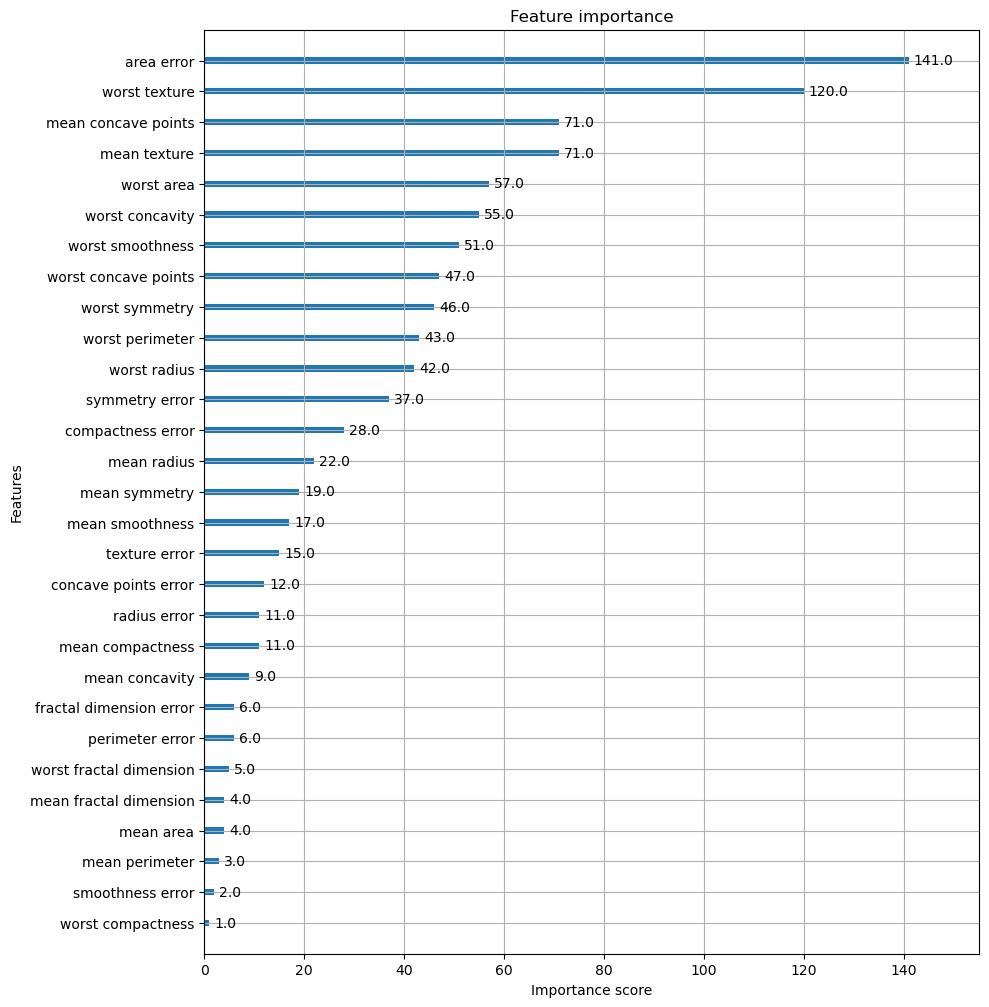

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)
plt.savefig('p239_xgb_feature_importance.tif', format='tif', dpi=300, bbox_inches='tight')

### 사이킷런 래퍼 XGBoost의 개요 및 적용

In [15]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

#Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력.
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [16]:
get_clf_eval(y_test , w_preds, w_pred_proba)

오차 행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870,    F1: 0.9806, AUC:0.9951


In [18]:
from xgboost import XGBClassifier
evals = [(X_test, y_test)]
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3,
                             early_stopping_rounds=100,
                             eval_metric="logloss")

xgb_wrapper.fit(X_train, y_train,
                eval_set=evals, verbose=True)

ws100_preds = xgb_wrapper.predict(X_test)
ws100_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.56499


[1]	validation_0-logloss:0.50615
[2]	validation_0-logloss:0.45818
[3]	validation_0-logloss:0.41774
[4]	validation_0-logloss:0.38060
[5]	validation_0-logloss:0.35098
[6]	validation_0-logloss:0.32552
[7]	validation_0-logloss:0.30095
[8]	validation_0-logloss:0.28167
[9]	validation_0-logloss:0.26239
[10]	validation_0-logloss:0.24797
[11]	validation_0-logloss:0.23210
[12]	validation_0-logloss:0.22060
[13]	validation_0-logloss:0.20778
[14]	validation_0-logloss:0.19775
[15]	validation_0-logloss:0.18975
[16]	validation_0-logloss:0.18064
[17]	validation_0-logloss:0.17250
[18]	validation_0-logloss:0.16517
[19]	validation_0-logloss:0.15833
[20]	validation_0-logloss:0.15442
[21]	validation_0-logloss:0.14640
[22]	validation_0-logloss:0.13943
[23]	validation_0-logloss:0.13421
[24]	validation_0-logloss:0.13041
[25]	validation_0-logloss:0.12705
[26]	validation_0-logloss:0.12288
[27]	validation_0-logloss:0.11970
[28]	validation_0-logloss:0.11748
[29]	validation_0-logloss:0.11270
[30]	validation_0-loglo

In [19]:
get_clf_eval(y_test , ws100_preds, ws100_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870,    F1: 0.9744, AUC:0.9951


In [20]:
# early_stopping_rounds를 10으로 설정하고 재 학습. 
xgb_wrapper.fit(X_train, y_train, eval_set=evals,verbose=True)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test , ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.56499
[1]	validation_0-logloss:0.50615
[2]	validation_0-logloss:0.45818
[3]	validation_0-logloss:0.41774
[4]	validation_0-logloss:0.38060
[5]	validation_0-logloss:0.35098
[6]	validation_0-logloss:0.32552
[7]	validation_0-logloss:0.30095
[8]	validation_0-logloss:0.28167
[9]	validation_0-logloss:0.26239
[10]	validation_0-logloss:0.24797
[11]	validation_0-logloss:0.23210
[12]	validation_0-logloss:0.22060
[13]	validation_0-logloss:0.20778
[14]	validation_0-logloss:0.19775
[15]	validation_0-logloss:0.18975
[16]	validation_0-logloss:0.18064
[17]	validation_0-logloss:0.17250
[18]	validation_0-logloss:0.16517
[19]	validation_0-logloss:0.15833
[20]	validation_0-logloss:0.15442
[21]	validation_0-logloss:0.14640
[22]	validation_0-logloss:0.13943
[23]	validation_0-logloss:0.13421
[24]	validation_0-logloss:0.13041
[25]	validation_0-logloss:0.12705
[26]	validation_0-logloss:0.12288
[27]	validation_0-logloss:0.11970
[28]	validation_0-logloss:0.11748
[29]	validation_0-loglos

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

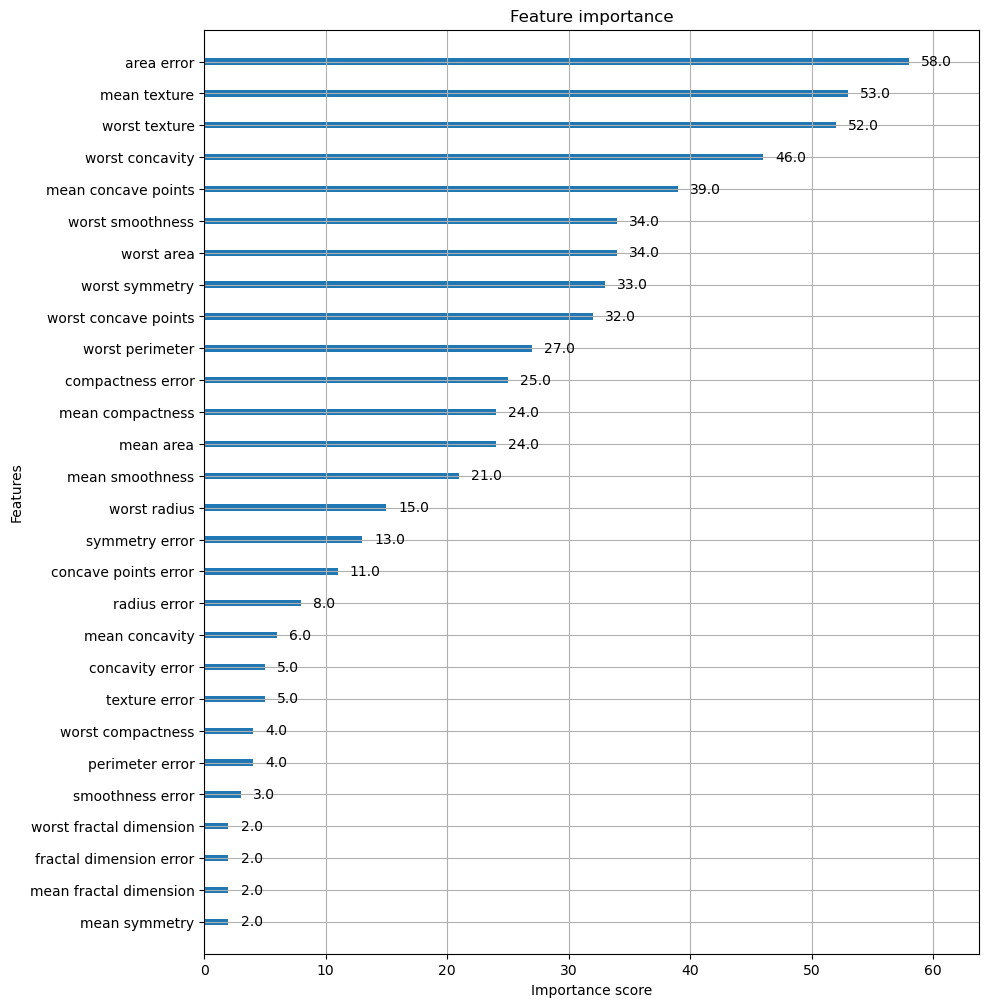

In [21]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
# 사이킷런 래퍼 클래스를 입력해도 무방. 
plot_importance(xgb_wrapper, ax=ax)

### 4.7 LightGBM

LightGBM(Light Gradient Boosting Machine)은 GBM 계열의 트리 기반 앙상블 학습 알고리즘이다.  
일반적인 GBM 계열 알고리즘이 트리의 균형을 맞추며 분할하는 것과 달리, LightGBM은 리프 중심 트리 분할 방식(Leaf-wise Tree Growth)을 사용한다.

리프 중심 트리 분할 방식은 트리 전체의 균형을 맞추기보다, 손실 값이 가장 큰 리프 노드를 계속 분할하여 예측 오류를 줄이는 방식이다.  
이러한 방식은 학습 속도를 높이고 메모리 사용량을 줄이는 데 효과적이며, 일반적으로 XGBoost보다 학습 시간이 짧다는 장점이 있다.

하지만 데이터 수가 적은 경우에는 특정 리프 노드가 과도하게 분할되면서 과적합(overfitting)이 발생하기 쉽다는 단점이 있다.  
따라서 LightGBM을 사용할 때는 데이터 크기와 모델 복잡도를 고려하여 하이퍼파라미터를 적절히 조정해야 한다.

In [22]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']= dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정.
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능.
evals = [(X_tr, y_tr), (X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, 
                 eval_set=evals)
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [ ]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9923


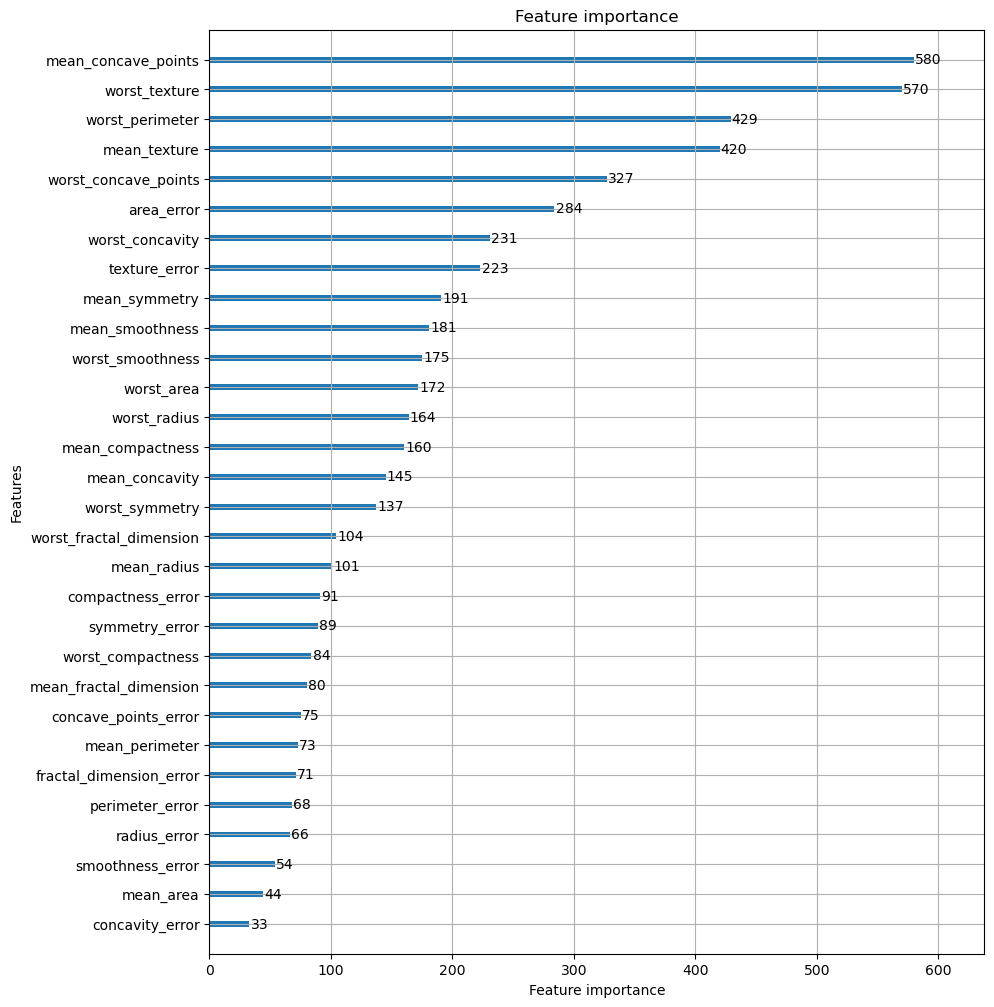

In [25]:
# plot_importance( )를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)
plt.savefig('lightgbm_feature_importance.tif', format='tif', dpi=300, bbox_inches='tight')

### 4.8 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼파라미터 튜닝

베이지안 최적화(Bayesian Optimization)는 목적 함수의 식을 명확히 알 수 없는 블랙박스 함수에서 최적의 입력값을 찾는 최적화 기법이다.  
즉, 함수의 내부 구조를 직접 알 수 없더라도, 가능한 적은 시도를 통해 목적 함수의 반환값을 최대화하거나 최소화하는 입력값을 빠르고 효과적으로 탐색한다.

베이지안 최적화는 크게 대체 모델(Surrogate Model)과 획득 함수(Acquisition Function)를 이용하여 동작한다.  
대체 모델은 기존에 탐색한 입력값과 결과값을 바탕으로 목적 함수의 형태를 예측하는 모델이다.  
획득 함수는 대체 모델의 예측 결과를 바탕으로 다음에 탐색할 가능성이 높은 최적 입력값을 선택한다.

이후 선택된 입력값을 실제 목적 함수에 적용하여 결과를 얻고, 그 결과를 다시 대체 모델에 반영하면서 점차 최적의 하이퍼파라미터 조합을 찾아간다.

HyperOpt는 이러한 베이지안 최적화 방식을 기반으로 하이퍼파라미터 튜닝을 수행할 수 있는 대표적인 라이브러리이다.  
HyperOpt를 사용하면 탐색 공간을 설정한 뒤, 모델의 성능을 가장 좋게 만드는 하이퍼파라미터 조합을 자동으로 탐색할 수 있다.

In [3]:
pip install hyperopt

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------------- ------------- 1.0/1.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.0 MB/s  0:00:00

   ---------------------------------------- 0/3 [py4j]
   ---------------------------------------- 0/3 [py4j]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- ---------------

In [4]:
from hyperopt import hp

# -10 ~ 10 사이의 1 간격을 가지는 입력 변수 x와 -15 ~ 15 사이의 1 간격을 가지는 입력 변수 y를 설정.
search_space = {'x': hp.quniform('x', -10, 10, 1),
                'y': hp.quniform('y', -15, 15, 1)}


c:\Users\USER\anaconda3\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
from hyperopt import STATUS_OK

# 목적 함수를 생성. 변숫값과 변수 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y
    
    return retval

In [6]:
from hyperopt import fmin, tpe, Trials
import numpy as np

# 입력 결괏값을 저장한 Trials 객체값 생성.
trial_val = Trials()

# 목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번의 입력값 시도(max_evals=5)로 찾아냄.
best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5
               , trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_01)

100%|██████████| 5/5 [00:00<00:00, 253.95trial/s, best loss: -224.0]
best: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [7]:
trial_val = Trials()

# max_evals를 20회로 늘려서 재테스트
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=20
               , trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_02)

100%|██████████| 20/20 [00:00<00:00, 352.36trial/s, best loss: -296.0]
best: {'x': np.float64(2.0), 'y': np.float64(15.0)}


In [8]:
# fmin( )에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적 함수 반환값들이 저장됨
# 리스트 내부의 개별 원소는 {'loss':함수 반환값, 'status':반환 상태값} 와 같은 딕셔너리임. 
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [9]:
# Trials 객체의 vals 속성에 {'입력변수명':개별 수행 시마다 입력된 값 리스트} 형태로 저장됨.
print(trial_val.vals)

{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0), np.float64(2.0), np.float64(10.0), np.float64(-9.0), np.float64(-8.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(9.0), np.float64(6.0), np.float64(9.0), np.float64(2.0), np.float64(-2.0), np.float64(-4.0), np.float64(7.0), np.float64(-0.0)], 'y': [np.float64(5.0), np.float64(10.0), np.float64(-2.0), np.float64(12.0), np.float64(1.0), np.float64(15.0), np.float64(7.0), np.float64(-10.0), np.float64(0.0), np.float64(-5.0), np.float64(-3.0), np.float64(2.0), np.float64(4.0), np.float64(10.0), np.float64(3.0), np.float64(3.0), np.float64(-14.0), np.float64(-8.0), np.float64(11.0), np.float64(-0.0)]}


In [10]:
import pandas as pd

# results에서 loss 키값에 해당하는 밸류들을 추출하여 list로 생성. 
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# DataFrame으로 생성.
result_df = pd.DataFrame({'x': trial_val.vals['x'], 'y': trial_val.vals['y'], 'losses': losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


### HyperOpt를 이용한  XGBoost 하이퍼 파라미터 최적화

In [11]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']= dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

In [12]:
# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

# 앞에서 추출한 학습 데이터를 다시 학습과 검증 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )

In [14]:
from hyperopt import hp

# max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간격으로
# colsample_bytree는 0.5에서 1사이, learning_rate는 0.01에서 0.2 사이 정규 분포된 값으로 검색.
xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1), 
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
                   }

In [15]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

# fmin()에서 입력된 search_space 값으로 입력된 모든 값은 실수형임.
# XGBClassifier의 정수형 하이퍼 파라미터는 정수형 변환을 해줘야 함.
# 정확도는 높을수록 더 좋은 수치임. -1 * 정확도를 곱해서 큰 정확도 값일수록 최소가 되도록 변환
def objective_func(search_space):
    # 수행 시간 절약을 위해 nestimators는 100으로 축소
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate=search_space['learning_rate'],
                            colsample_bytree=search_space['colsample_bytree'],
                            eval_metric='logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)
    
    # accuracy는 cv=3 개수만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함.
    return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

In [16]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수를 지정합니다.
            trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:', best)

100%|██████████| 50/50 [00:26<00:00,  1.89trial/s, best loss: -0.9692401533635412]
best: {'colsample_bytree': np.float64(0.7816916965882073), 'learning_rate': np.float64(0.15978354626451718), 'max_depth': np.float64(20.0), 'min_child_weight': np.float64(2.0)}


In [17]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.78169, learning_rate:0.15978, max_depth:20, min_child_weight:2


In [19]:
xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    colsample_bytree=round(best['colsample_bytree'], 5),
    early_stopping_rounds=50,
    eval_metric='logloss'
)

evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(
    X_tr,
    y_tr,
    eval_set=evals,
    verbose=True
)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.54379	validation_1-logloss:0.58107
[1]	validation_0-logloss:0.45190	validation_1-logloss:0.51622
[2]	validation_0-logloss:0.38041	validation_1-logloss:0.45865
[3]	validation_0-logloss:0.32496	validation_1-logloss:0.41740
[4]	validation_0-logloss:0.28110	validation_1-logloss:0.38619
[5]	validation_0-logloss:0.24305	validation_1-logloss:0.35807
[6]	validation_0-logloss:0.21292	validation_1-logloss:0.34329
[7]	validation_0-logloss:0.18874	validation_1-logloss:0.32475
[8]	validation_0-logloss:0.16768	validation_1-logloss:0.31701
[9]	validation_0-logloss:0.14904	validation_1-logloss:0.30362
[10]	validation_0-logloss:0.13466	validation_1-logloss:0.29923
[11]	validation_0-logloss:0.12170	validation_1-logloss:0.29388
[12]	validation_0-logloss:0.11059	validation_1-logloss:0.28602
[13]	validation_0-logloss:0.09966	validation_1-logloss:0.27923
[14]	validation_0-logloss:0.09056	validation_1-logloss:0.27397
[15]	validation_0-logloss:0.08342	validation_1-logloss:0.27112


[16]	validation_0-logloss:0.07772	validation_1-logloss:0.26756
[17]	validation_0-logloss:0.07200	validation_1-logloss:0.26441
[18]	validation_0-logloss:0.06673	validation_1-logloss:0.26491
[19]	validation_0-logloss:0.06159	validation_1-logloss:0.26502
[20]	validation_0-logloss:0.05730	validation_1-logloss:0.26046
[21]	validation_0-logloss:0.05375	validation_1-logloss:0.25800
[22]	validation_0-logloss:0.05111	validation_1-logloss:0.25501
[23]	validation_0-logloss:0.04817	validation_1-logloss:0.25631
[24]	validation_0-logloss:0.04524	validation_1-logloss:0.25479
[25]	validation_0-logloss:0.04317	validation_1-logloss:0.25756
[26]	validation_0-logloss:0.04104	validation_1-logloss:0.25756
[27]	validation_0-logloss:0.03859	validation_1-logloss:0.25890
[28]	validation_0-logloss:0.03710	validation_1-logloss:0.26195
[29]	validation_0-logloss:0.03559	validation_1-logloss:0.26242
[30]	validation_0-logloss:0.03411	validation_1-logloss:0.26149
[31]	validation_0-logloss:0.03286	validation_1-logloss: